In [1]:
# %%file SolveLoads.py
import sys
sys.path.append('../')

import numpy as np
from Equilibrium import *
from constants import *

def SolveACLoads(cg, acf, acb):
    Weight = PointLoad([0, - mTO * 9.81, 0], [cg, 0, 0])
    LFront = PointLoad([0, 1, 0], [acf, 0, 0])
    LBack = PointLoad([0, 1, 0], [acb, 0, 0])
    motion = EquilibriumEquation(kloads = [Weight], ukloads=[LFront, LBack])
    motion.SetupEquation()
    return list(motion.SolveEquation())

def SolveWingLoads(MAC, b, Lwing, Dwing, mWing, TpE, nE):
    pos = np.linspace(0, b / 2)
    WingWeight = RunningLoad([[0]*len(pos), [- mWing * 9.81 / b]*len(pos)], pos, axis=2)
    Lift = RunningLoad([[0]*len(pos), [Lwing / b] * len(pos)], pos, axis=2)
    Drag = RunningLoad([[Dwing / b] * len(pos), [0]*len(pos)], pos, axis=2)
    Thrust = [PointLoad([-TpE, 0, 0], [0, 0, i]) for i in np.linspace(0, b/2, round(N_cruise/4))]
    MomentAC = Moment(value=[0, 0, 30])

    Fixedx = PointLoad([1, 0, 0], [0.5 * MAC, 0, 0])
    Fixedy = PointLoad([0, 1, 0], [0.5 * MAC, 0, 0])
    Fixedz = PointLoad([0, 0, 1], [0.5 * MAC, 0, 0])

    FixedMomentx, FixedMomenty, FixedMomentz = Moment([1, 0, 0]), Moment([0, 1, 0]), Moment([0, 0, 1])
    wingequation = EquilibriumEquation(kloads=[WingWeight, Lift, Drag, MomentAC] + Thrust,
                                       ukloads=[Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz])
    wingequation.SetupEquation()
    return wingequation

In [2]:
print(ACLoads := SolveACLoads(1.95, 0.5, 3.5))
wingequation = SolveWingLoads(0.2, 11.2, ACLoads[0], 800, mTO / 8, 100, 3)
print(WingLoads := list(wingequation.SolveEquation()))

[9787.273500000003, 9155.8365]
[0.0, -3709.6923750000014, 0.0, 10387.138650000004, 0.0, 340.9692375000002]


In [3]:
from IPython.display import Math, display
show = lambda func: display(Math(func.__str__()))

In [4]:
# uk: [ Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz ]
# C1: [ -700.      -7419.38475     0.      20774.2773    -1960.       0. ]
# C2: [ -600.      -7103.66625     0.      19890.2655    -1680.       0. ]
# C3: [ -800.    -14883.87214286   0.     41674.842      -2240.       0. ]

In [5]:
# %%file Analysis.py
import numpy as np
from MathFunctions.Trigonometry import pi
from MathFunctions.Mechanics import StepFunction
import pandas as pd

class WingBox:
    def __init__(self, thickness, base, height):
        self.b, self.h, self.t = base, height, thickness
    
    Area = lambda self: self.b * self.h - (self.b - 2 * self.t) * (self.h - 2 * self.t)

    Ixx = lambda self: (self.t * self.h ** 3 + self.b * self.t ** 3) / 6 + (self.t * self.b * self.h ** 2) / 2
    
    Iyy = lambda self: (self.t ** 3 * self.h + self.b ** 3 * self.t) / 6 + (self.t * self.h * self.b ** 2) / 2
    
    Vc = Ixy = lambda self: 0
    
    def Vshear(self, Vy, x, y):
        Ixx = self.Ixx()
        inrge = lambda l1, u1, l2, u2: l1 <= x <= u1 and l2 <= y <= u2
        vit = - Vy * self.t / Ixx
        if inrge(0, self.b/2, -self.h/2, -self.h/2 + self.t):
            return vit * (-self.h * x / 2)
        elif inrge(self.b/2-self.t, self.b/2, -self.h/2, self.h/2):
            s = self.h/2 + y
            return vit * (0.5 * s * s - self.h * s / 2) + self.Vshear(Vy, self.b/2, -self.h/2)
        elif inrge(-self.b/2, self.b/2, self.h/2-self.t, self.h/2):
            s = self.b/2 - x
            return vit * (self.h*s/2) + self.Vshear(Vy, self.b/2, self.h/2)
        elif inrge(-self.b/2, -self.b/2+self.t, -self.h/2, self.h/2):
            s = self.h/2 - y
            return vit * (-0.5 * s * s + self.h * s / 2) + self.Vshear(Vy, -self.b/2, self.h/2)
        elif inrge(-self.b/2, 0, -self.h/2, -self.h/2+self.t):
            return vit * (-self.h * (x + self.b/2) / 2) + self.Vshear(Vy, -self.b/2, -self.h/2)
        else:
            raise ValueError(f"Invalid Coordinates Supplied: {(x, y) = }")

    def Hshear(self, Vx, x, y):
        Iyy = self.Iyy()
        inrge = lambda l1, u1, l2, u2: l1 <= x <= u1 and l2 <= y <= u2
        vit = - Vx * self.t / Iyy
        if inrge(-self.b/2, -self.b/2+self.t, -self.h/2, 0):
            return vit * (self.b * y / 2)
        elif inrge(-self.b/2, self.b/2, -self.h/2, -self.h/2+self.t):
            s = x + self.b/2
            return vit * (0.5 * s * s - self.b * s / 2) + self.Hshear(Vx, -self.b/2, -self.h/2)
        elif inrge(self.b/2 -self.t, self.b, -self.h/2, self.h/2):
            return vit * (self.b * (y + self.h/2) / 2) + self.Hshear(Vx, self.b/2, -self.h/2)
        elif inrge(-self.b/2, self.b/2, self.h/2-self.t, self.h/2):
            s = -x + self.b/2
            return vit * (-0.5 * s * s + self.b * s / 2) + self.Hshear(Vx, self.b/2, self.h/2)
        elif inrge(-self.b/2, -self.b/2+self.t, 0, self.h/2):
            return vit * (-self.b * (self.h/2-y) / 2) + self.Hshear(Vx, -self.b/2, self.h/2)
        else:
            raise ValueError(f"Invalid Coordinates Supplied: {(x, y) = }")
    
    @staticmethod
    def buckling(shorterSideOfSkin, skinThickness, E, v=0.33):
        C = 5.41 # SSCS Support
        b = shorterSideOfSkin
        t = skinThickness
        return C * pi * pi * E * (t / b) ** 2 / (12 * (1 - v * v))
    
    q = lambda self, x, y, Vx=0, Vy=0, T=0: self.Vshear(Vy, x, y) + self.Hshear(Vx, x, y) + T / (2 * self.Area())
    tau = lambda self, x, y, Vx=0, Vy=0, T=0: self.q(x, y, Vx, Vy, T) / self.t
    o = lambda self, x, y, Mx=0, My=0: My * x / self.Iyy() + Mx * y / self.Ixx()

class WingStructure:
    def __init__(self, wingequation):
        WingLoads = wingequation.SolveEquation()
        self.RFx, self.RFy, self.RFz = WingLoads[:3]
        self.RMx, self.RMy, self.RMz = WingLoads[3:] # WingWeight, Lift, Drag, MomentAC, Thrust
        self.W, self.L, self.D, self.Mac, *self.T = wingequation.k

        self.N = self.Vx = self.Vy = self.Mz = self.Mx = self.My = None
        self.v = self.w = self.phi = None

    def compute_loading(self):
        self.N = StepFunction([[self.RFz, 0, 0]])
        qxzcoef = list(np.polyfit(self.W.p, self.W.v[0] + self.D.v[0] + self.L.v[0], 4))[::-1]
        qyzcoef = list(np.polyfit(self.W.p, self.W.v[1] + self.D.v[1] + self.L.v[1], 4))[::-1]
        qxz = StepFunction([[xi, 0, i] for i, xi in enumerate(qxzcoef)])
        qyz = StepFunction([[yi, 0, i] for i, yi in enumerate(qyzcoef)])
        self.Vx = StepFunction([[self.RFx, 0, 0]] + [[T.f[0], T.p[2], 0] for T in self.T]) + qxz.integral()
        self.Vy = StepFunction([[self.RFy, 0, 0]] + [[T.f[1], T.p[2], 0] for T in self.T]) + qyz.integral()
        self.Mz = self.L.pa[0] * qyz.integral() - self.L.pa[1] * qxz.integral() + self.RMz
        self.My, self.Mx = self.Vx.integral(-self.RMy), self.Vy.integral(self.RMx)
        return [self.N, self.Vx, self.Vy, self.Mx, self.My, self.Mz]

    def compute_deflections(self, E, Ixx, Iyy=None):
        Iyy = Ixx if Iyy is None else Iyy
        self.v = -self.My.integral().integral() / (E * Ixx)
        self.w = self.Mx.integral().integral() / (E * Iyy)
        return self.v, self.w

    def create_nvm(self, b):
        x = np.linspace(0, b/2, 100)
        df = pd.DataFrame({'z': x} | {ln: [lv(xi) for xi in x] for ln, lv in \
                            zip(('v', 'w', 'Mx', 'My', 'Mz', 'N', 'Vx', 'Vy'), 
                                (self.v, self.w, self.Mx, self.My, self.Mz, self.N, self.Vx, self.Vy))}) \
                                    .set_index('z')
        for col in df.columns:
            df.plot(y=col)
    

In [6]:
wingbox = WingBox(5e-3, 2, 0.5)
wingbox.Hshear(100, 0, wingbox.h/2)

-32.14282844390318

In [7]:
wing = WingStructure(wingequation)
wing.compute_loading()
show(wing.My)
show(wing.compute_deflections(60e9, 1.005e-4, 1.005e-2)[0])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

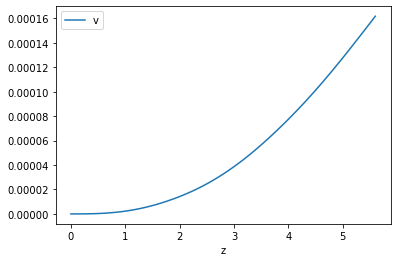

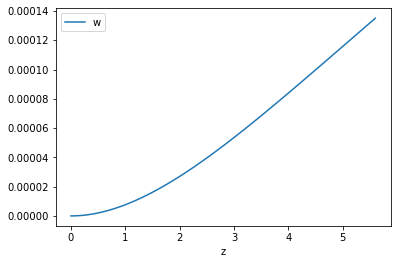

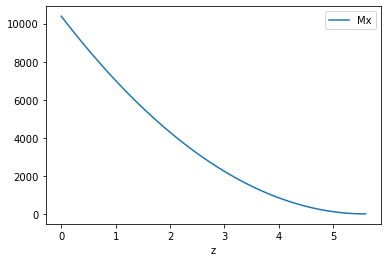

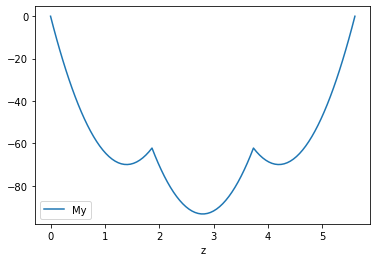

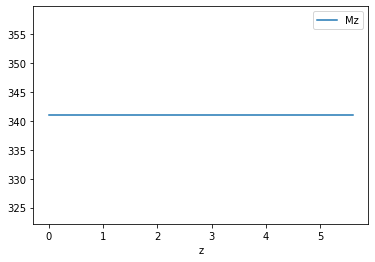

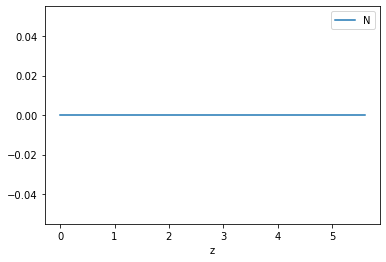

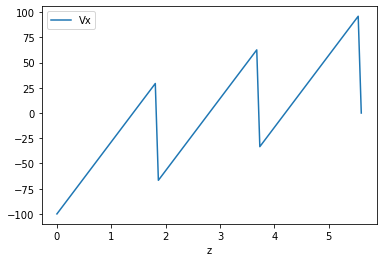

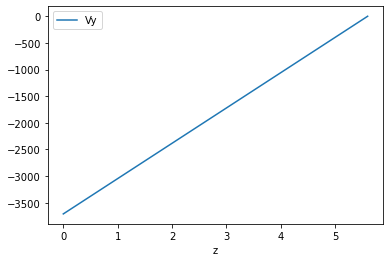

In [8]:
wing.create_nvm(11.2)

In [9]:
import numpy as np

materials = pd.read_html('https://mechanicalc.com/reference/material-properties-tables')
matdfs = {"Carbon Steel": materials[1], "Alloy Steel": materials[2], "Stainless Steel": materials[3], "Cast Iron": materials[4],
         "Aluminum Alloys": materials[5], "Nickel Alloys": materials[6], "Copper Alloys": materials[7], "Titanium Alloys": materials[8]}

for m in matdfs:
    matdfs[m]['Class'] = m
    matdfs[m] = matdfs[m].iloc[:-1]
df = pd.concat(matdfs.values())
description = {}
num_cols = ['YieldStrength [ksi]', 'UltimateStrength [ksi]', 'Elongation%', 'Density[lb/in3]', "Poisson'sRatio"]
for num in num_cols:
    tit = ''.join([letter for letter in num if letter not in ['[', ']', '/', '3', ' ', '%', "'", "'"] and letter.upper() == letter])
    description[tit] = num
    df[tit] = pd.to_numeric(df[num], errors='coerce')

df.drop(columns=num_cols, inplace=True)

df[['YS', 'US']] *= 6.89476e6 # psi --> Pa
df['ElasticModulus [psi]'] = df['ElasticModulus [psi]'].apply(lambda x: np.mean(np.float64(x.replace('e6', '').split(' - '))) * 6.89476e9)
df['D'] *= 27679.9 # lb/in3 --> kg/m3
df.E /= 100 # %
df.rename(columns={'E': 'elong', 'ElasticModulus [psi]': 'E', 'D': 'rho', 'US': 'oult', 'YS': 'oyield', 'PR': 'v'}, inplace=True)
df = df.replace('---', np.nan)
df.head()

,Material,Condition,E,Class,oyield,oult,elong,rho,v
0,AISI 1020,Hot Rolled,1.999480e+11,Carbon Steel,220632320.0,344738000.0,0.25,7833.4117,0.32
1,AISI 1020,Cold Worked,1.999480e+11,Carbon Steel,413685600.0,482633200.0,0.05,7833.4117,0.32
2,AISI 1020,Stress Relieved,1.999480e+11,Carbon Steel,344738000.0,448159400.0,0.10,7833.4117,0.32
3,AISI 1020,Annealed,1.999480e+11,Carbon Steel,193053280.0,330948480.0,0.30,7833.4117,0.32
4,AISI 1020,Normalized,1.999480e+11,Carbon Steel,234421840.0,379211800.0,0.22,7833.4117,0.32


In [10]:
paris = pd.read_json('materials.json')

def transform(x):
    clm = [col for col in paris.columns if col in x['Class']]
    if len(clm):
        x['ParisA'] = paris[clm[0]]['A']
        x['Parism'] = paris[clm[0]]['m']
    return x

df = df.apply(transform, axis=1)
df.head()

,Class,Condition,E,Material,ParisA,Parism,elong,oult,oyield,rho,v
0,Carbon Steel,Hot Rolled,1.999480e+11,AISI 1020,1.000000e-11,3.0,0.25,344738000.0,220632320.0,7833.4117,0.32
1,Carbon Steel,Cold Worked,1.999480e+11,AISI 1020,1.000000e-11,3.0,0.05,482633200.0,413685600.0,7833.4117,0.32
2,Carbon Steel,Stress Relieved,1.999480e+11,AISI 1020,1.000000e-11,3.0,0.10,448159400.0,344738000.0,7833.4117,0.32
3,Carbon Steel,Annealed,1.999480e+11,AISI 1020,1.000000e-11,3.0,0.30,330948480.0,193053280.0,7833.4117,0.32
4,Carbon Steel,Normalized,1.999480e+11,AISI 1020,1.000000e-11,3.0,0.22,379211800.0,234421840.0,7833.4117,0.32


In [11]:
df.to_csv('materials.csv', index=False)

In [12]:
import pandas as pd
from scipy.integrate import quad
from MathFunctions.Trigonometry import cos, pi

class Material:
    def __init__(self, E, density, o_yield, o_ult, Paris=(None, None), name=None, **others):
        self.E, self.rho, self.oy, self.oult = E, density, o_yield, o_ult
        self.C, self.m = Paris
        self.props = others
        self.name = name
    
    __repr__ = __str__ = lambda self: (self.name if self.name else "Material")+f"(E={self.E}, ρ={self.rho}, σy={self.oy}, σult={self.oult})"
    
    @staticmethod
    def load(file='materials.csv', material='Al 6061', Condition='T6'):
        df = pd.read_csv(file)
        check = df[df['Material'] == material]
        if len(check) == 0:
            raise KeyError(f'No {material = } could be found')
        elif len(check) == 1:
            mat = check.iloc[0]
        else:
            mat = check[check['Condition'] == Condition].iloc[0]
        return Material(mat.E, mat.rho, mat.oyield, mat.oult, (mat.ParisA, mat.Parism), mat.Material)
        
    @staticmethod
    def beta(aow, center=True): 
        return (1/cos(pi * aow)) ** 0.5 if center else 1.1215 # pg 131

    @staticmethod
    def StressConcentration(beta, a, o):
        return beta * o * (pi * a) ** 0.5
    
    def ParisFatigueN(self, a, dS, w, af):
        def integrand(a, dS, w):
            beta = self.beta(a/w)
            return (1/self.StressConcentration(beta, a, dS))**self.m
        N = 1/self.C * quad((lambda a: integrand(a, dS, w)), a, af)[0]
        return N


In [13]:
aluminum = Material.load()
print(aluminum)
aluminum.ParisFatigueN(1e-3, 1e6, 1.5, 1e-2)
# material.StressConcentration(1, 1e-5, 10e6)

Al 6061(E=68258124000.0, ρ=2712.6302, σy=241316600.0, σult=262000880.0)


7.765963037947122e-06

Component       Mass[kg]             fraction of OEM           fraction of MTOM
--------------------------------------------------------------------------------
Front wing      119.45329511024428   0.09637744773327225       0.06638388864833066
Back wing       119.45329511024428   0.09637744773327225       0.06638388864833066
Fuselage        90.21643376125438    0.07278852895169609       0.05013606102309187
Landing gear    77.24                0.06231886743724943       0.04292465565277929
Propulsion      400.0                0.32272846937985206       0.22229236485126508
Cargo           85                   0.0                       0.04723712753089383
Battery         433.069              0.3494092387646579        0.24066983038443132
Payload         475                  0.0                       0.3832400573885743

Where OEM is 1239.432023981743kg with CG of 2.0m, and MTOM is 1799.432023981743kg with CG of 1.9627660288874131m


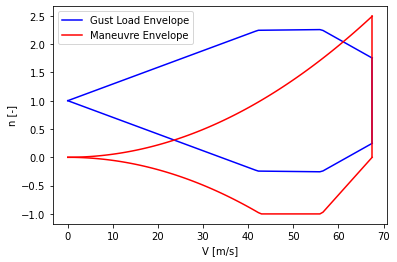

In [14]:
import sys
sys.path.append('../')
sys.path.append('../Sizing')
from constants import *
from maneuvre import plotgustenv, plotmaneuvrenv

from cg_est import Wing, Fuselage, LandingGear, Propulsion, Weight
from SolveLoads import SolveACLoads, SolveWingLoads
from Analysis import WingBox, WingStructure

config = 1
WoS = 1745
Pmax = 8.77182
mProp = 400 / N_cruise

nmax = max(plotgustenv(0.75 * V_cruise, V_cruise, CLalpha_back, WoS), plotmaneuvrenv(WoS, V_cruise, CLmax_back))
w = Weight(95, Wing(mTO, S_front, S_back, 1.5*nmax, AR, [0.4, 3.6], config),
           Fuselage(mTO, Pmax, l_fus, 5, l_fus/2, config),
          LandingGear(mTO, l_fus/2),
          Propulsion(N_cruise, [mProp]*N_cruise, pos_prop=[3.6]*int(N_cruise/2) + [0.4]*int(N_cruise/2)),
          cargo_m, cargo_p, Bat_mass, l_fus/2, [0.8, 1.3, 1.3, 2.5, 2.5])

w.print_weight_fractions()

LpWing = SolveACLoads(w.mtom_cg, *w.wing.pos)
wingEquation = SolveWingLoads(MAC1, (S_front * AR) ** 0.5, LpWing[0], mTO / LD_ratio, w.wing.get_weight()[0], 
                              mTO / (LD_ratio*N_cruise), N_cruise)

In [15]:
from IPython.display import Math, display
wingEquation.SetupEquation()
Fx, Fy, Fz, Mx, My, Mz = wingEquation.SolveEquation()
wingS = WingStructure(wingEquation)
N, Vx, Vy, Mx, My, Mz = wingS.compute_loading()
show = lambda func: display(Math(func.__str__()))
show(Vy)
show(Mx.derivative())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
box = WingBox(1e-3, 0.8 * c_r, 0.8 * 0.17 * c_r)
tau = lambda x, y, z: box.tau(x, y, Vx(z), Vy(z), My(z))
ozz = lambda x, y, z: box.o(x, y, Mx(z), My(z))

In [17]:
stresses = np.array([[ozz(x, y, 0) for x in np.linspace(-box.b/2, box.b/2)] for y in np.linspace(-box.h/2, box.h/2)], dtype='float64')
am = stresses.argmax()

stresses.flatten()[am]*1e-6

72.50898400724003

In [18]:
show("M_x(z)=")
show(Mx)
show("M_y(z)=")
show(My)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>